# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [30]:
STUDENT_NAME = "Nguyễn Phương Thảo"  # TODO: Họ và tên
STUDENT_ID = "2413202"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Phương Thảo (2413202)


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [32]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [33]:
# TODO N1
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [34]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [35]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [36]:
# TODO N2
train_feature_mean = X_train.mean(axis=0)
train_feature_std = X_train.std(axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [37]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [38]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [39]:
# TODO N3
correct_mask = (predicted_classes == true_labels)
high_confidence_mask = (confidence_scores >= confidence_threshold)
review_mask = (~correct_mask | ~high_confidence_mask)
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [40]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [41]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = normalized_batch[:, :, ::-1, :].copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->
1. Mỗi dòng đại diện cho 1 mẫu xe trong bộ 1985 Auto Imports.
2. Missing value trong CSV được kí hiệu bằng dấu chấm hỏi `?`.
3. `symboling` là mức đánh giá rủi ro bảo hiểm.

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [42]:
# TODO D1
raw_df = pd.read_csv('data/automobile_raw.csv')
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()

print("raw_shape:", raw_shape)
print("raw_missing_marker_count:", raw_missing_marker_count)

raw_shape: (205, 26)
raw_missing_marker_count: 59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [43]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [44]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()

print(missing_by_column)

symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base            0
length                0
width                 0
height                0
curb_weight           0
engine_type           0
num_cylinders         0
engine_size           0
fuel_system           0
bore                  4
stroke                4
compression_ratio     0
horsepower            2
peak_rpm              2
city_mpg              0
highway_mpg           0
price                 4
dtype: int64


In [45]:
df_clean.describe()

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
count,205.000000,164.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,201.000000,201.000000,205.000000,203.000000,203.000000,205.000000,205.000000,201.000000
mean,0.834146,122.000000,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329751,3.255423,10.142537,104.256158,5125.369458,25.219512,30.751220,13207.129353
std,1.245307,35.442168,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.273539,0.316717,3.972040,39.714369,479.334560,6.542142,6.886443,7947.066342
min,-2.000000,65.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,0.000000,94.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7775.000000
50%,1.000000,115.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,2.000000,150.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.590000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16500.000000
max,3.000000,256.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->
- Không fill tất cả numeric columns bằng cùng 1 giá trị vì các column không cùng thang đo đơn vị và phạm vi giá trị. Ví dụ: `symboling` có mean = 0.834146, giá trị từ [-2, 3], còn `normalized_losses` lại có mean = 122, giá trị từ [65, 256] --> Điền cùng 1 giá trị cho 2 cột này có thể tạo ra những điểm outlier cực đoan, gây ảnh hưởng đến mô hình.
- Với `price`, lựa chọn drop phù hợp hơn do số lượng missing value rất ít, chỉ có 4 giá trị, vì vậy drop các hàng này không gây ảnh hưởng lớn.
- Việc `normalized_losses` thiếu nhiều dữ liệu hơn sẽ giảm độ tin cậy khi phân tích rủi ro bảo hiểm. Nếu chọn drop thì sẽ làm mất đi 20% số lượng của tập dữ liệu. Nếu chọn fill bằng giá trị trung bình đơn giản, thì phân phối của cột này cũng sẽ bị biến dạng lớn, mất đi tính biến thiên thực tế.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [46]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [47]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [48]:
# TODO D4
price_index = -1
price_z = X_auto_scaled[:, price_index]
price_outlier_mask = (np.abs(price_z) > 2)
price_outliers = np.where(price_outlier_mask)[0]

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [49]:
# TODO D5
engine_size_arr = analysis_df["engine_size"].to_numpy()
price_arr = analysis_df["price"].to_numpy()
engine_price_corr = np.corrcoef(engine_size_arr, price_arr)
price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

print("engine_price_corr:\n", engine_price_corr)
print("\nprice_by_body_style:\n", price_by_body_style)

engine_price_corr:
 [[1.         0.87388695]
 [0.87388695 1.        ]]

price_by_body_style:
 body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

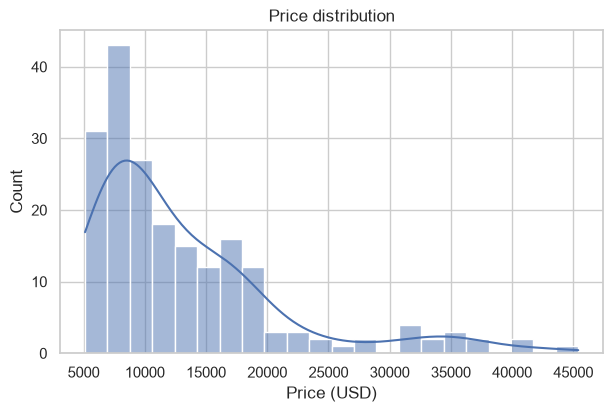

In [50]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.histplot(data=analysis_df, x='price', kde=True, bins=22, ax=ax)
ax.set_title("Price distribution")
ax.set_xlabel("Price (USD)")
plt.show()

**Nhận xét:**
 <!-- 1--2 câu -->
Price có phân phối lệch phải rõ rệt, các mẫu xe tập trung nhiều ở khoảng 5000 - 10000 USD.


## M2.2 Dataset có cân bằng theo body style không?

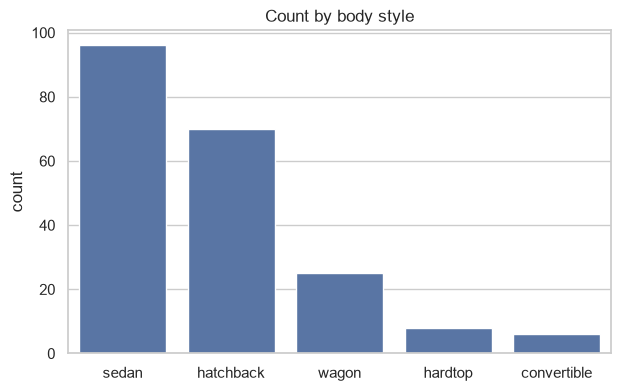

In [51]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots(figsize=(7, 4.2))
order = df_clean["body_style"].value_counts().index
sns.countplot(data=df_clean, x='body_style', order=order, ax=ax)
ax.set_xlabel("")
ax.set_title("Count by body style")
plt.show()

**Nhận xét:** 
<!-- 1--2 câu -->
Dataset không cân bằng theo body style. 2 loại xe `sedan` và `hatchback` chiếm phần lớn số lượng mẫu, trong khi 3 loại xe còn lại thì có số lượng mẫu rất ít.

## M2.3 Price khác nhau theo body style ra sao?

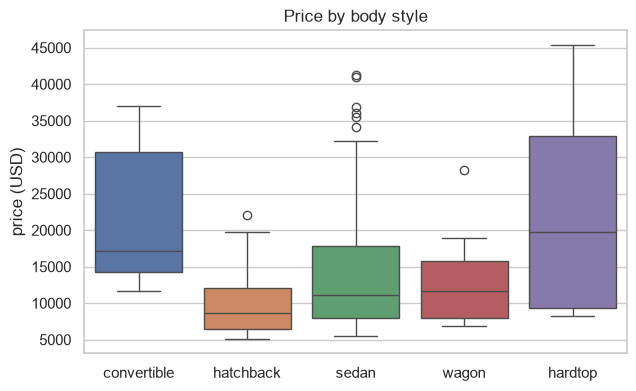

In [52]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.boxplot(data=df_clean, x='body_style', y='price', hue='body_style', ax=ax)
ax.set_title("Price by body style")
ax.set_xlabel("")
ax.set_ylabel("price (USD)")
plt.show()

**Nhận xét:** 
<!-- 1--2 câu -->
- Price của nhóm `convertible` và `hardtop` có giá trị trung vị và độ phân tán cao hơn hẳn nhóm `hatchback`, `sedan`, `wagon`.
- Sedan có nhiều điểm outlier nhất.

## M2.4 Engine size liên quan thế nào tới price?

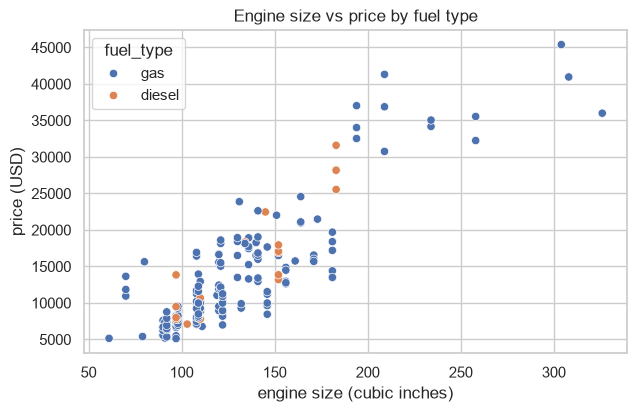

In [53]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.scatterplot(data=df_clean, x='engine_size', y='price', hue='fuel_type', ax=ax)
ax.set_title("Engine size vs price by fuel type")
ax.set_xlabel("engine size (cubic inches)")
ax.set_ylabel("price (USD)")
plt.show()

**Nhận xét:** 
<!-- 1--2 câu -->
- Các điểm dữ liệu tạo thành xu hướng đường thẳng đi lên --> `engine_size` và `price` có tương quan thuận.
- Dữ liệu giữa 2 loại `fuel_type` không cân bằng, `gas` có nhiều điểm dữ liệu hơn `diesel` rất nhiều. Nhìn chung, `diesel` có `engine_size` nhỏ hơn so với `gas`.

## M2.5 Các feature numeric tương quan ra sao?

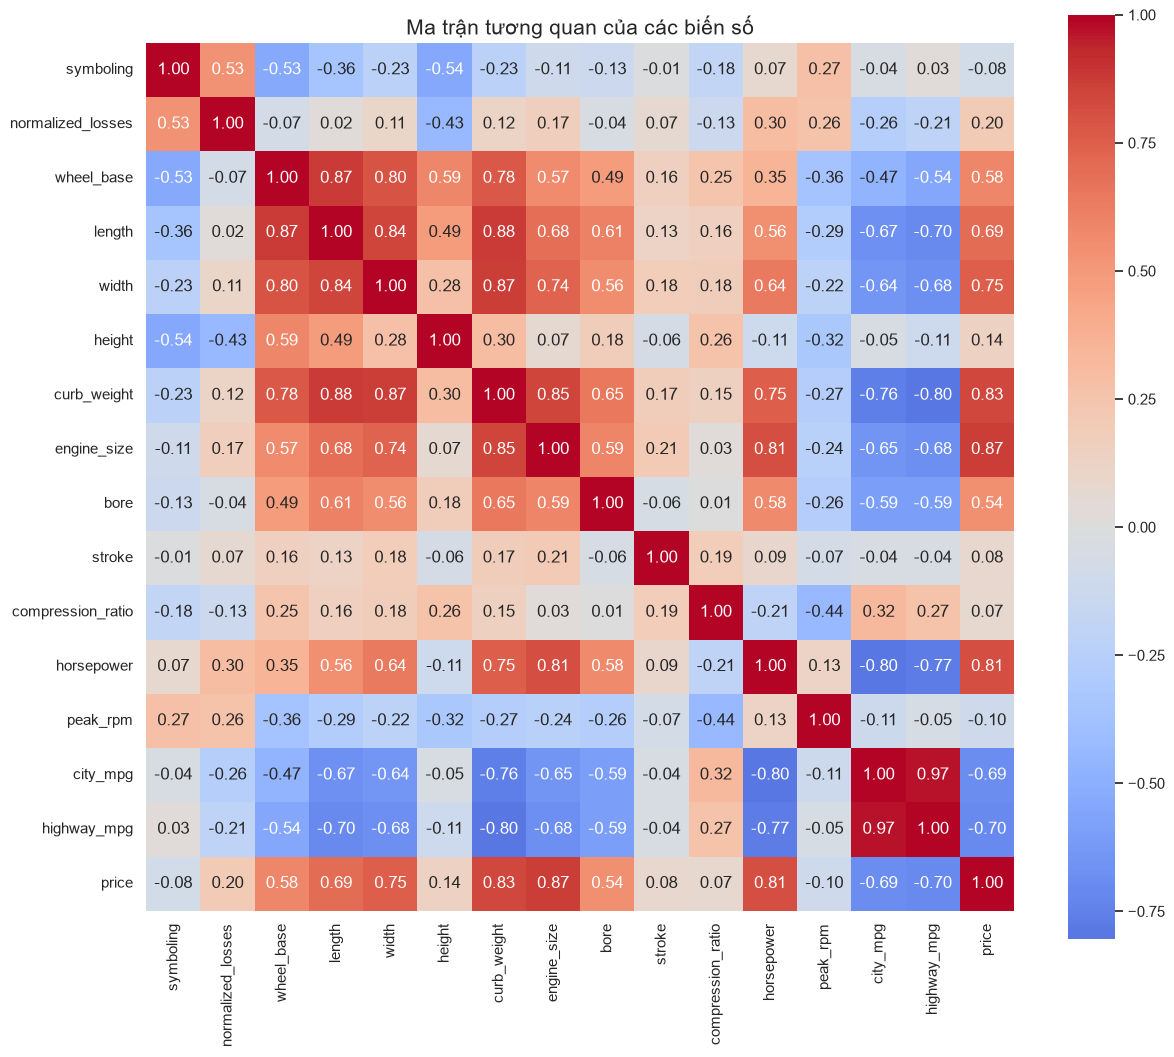

In [54]:
# TODO M2.5: correlation heatmap
corr = df_clean[NUMERIC_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0, square=True, ax=ax)
ax.set_title("Ma trận tương quan của các biến số", fontsize=15)
plt.show()


**Nhận xét:** 
<!-- 1--2 câu -->
- `city_mpg` và `highway_mpg` có tương quan mạnh nhất.
- biến mục tiêu `price` có tương quan dương mạnh với `engine_size`, `curb_weight`, `horsepower`, `width`, `length`. Ngoài ra, `price` còn có tương quan âm với `city_mpg` và `highway_mpg`.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Câu hỏi: `price` khác nhau như thế nào theo `drive_wheels` và `aspiration`?

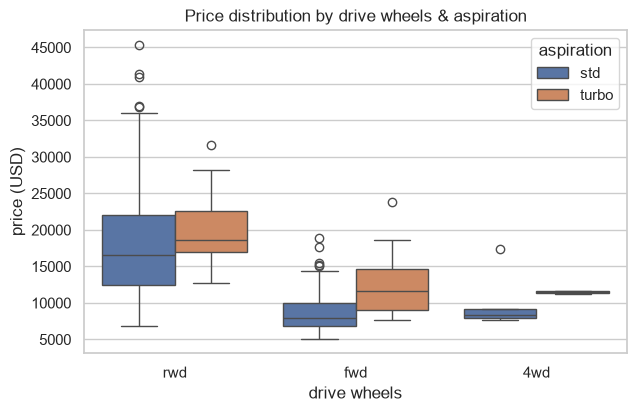

In [55]:
# TODO M2.6: biểu đồ tự chọn
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.boxplot(data=df_clean, x='drive_wheels', y='price', hue='aspiration', ax=ax)
ax.set_title("Price distribution by drive wheels & aspiration")
ax.set_xlabel("drive wheels")
ax.set_ylabel("price (USD)")
ax.legend(title="aspiration", loc="upper right")
ax.grid(True, axis="y")
plt.show()

**Nhận xét:** 
<!-- 1--2 câu -->
- `turbo` có giá cao hơn `std`.
- `rwd` có giá cao hơn `fwd`, `4wd`.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

Các phát hiện chính:
- `price` có phân phối lệch phải.
- `price` có tương quan mạnh nhất với `engine_size` (hệ số tương quan ~0.87).
- Kiểu thân xe `convertible` và `hardtop` có giá cao hơn `hatchback`, `sedan`, `wagon`.
- Mẫu xe với cơ chế nạp khí `turbo` có giá cao hơn `std`.
- Mẫu xe với hệ dẫn động `rwd` có giá cao hơn các loại khác.

2 hạn chế của dataset:
- Dataset có nhiều missing value ở cột `normalized_losses`, khiến các phân tích liên quan đến rủi ro bảo hiểm khó thực hiện, dễ bị sai lệch.
- Feature `body_style` có sự mất cân bằng về dữ liệu, gây khó khăn cho việc dự đoán trên các nhóm thiểu số.

Ví dụ về correlation không đồng nghĩa causation:
- `city_mpg` và `highway_mpg` có tương quan rất mạnh (hệ số tương quan ~0.97). Tuy nhiên, việc một chiếc xe tiết kiệm xăng khi đi trong phố (`city_mpg` cao) không phải là nguyên nhân khiến nó tiết kiệm xăng trên đường cao tốc (`highway_mpg` cao). Vì vậy, 2 biến này không có mối quan hệ nhân quả (causation). Việc cả `city_mpg` và `highway_mpg` cùng thay đổi là do chúng cùng chịu sự quyết định của một nhóm yếu tố khác của chiếc xe, ví dụ như `engine_size`, `engine_type`...

Câu hỏi nên phân tích tiếp: 
- Mức tổn thất bảo hiểm (`normalized_losses`) có mối liên hệ như thế nào với mức độ rủi ro bảo hiểm (`symboling`)? Liệu các dòng xe đắt tiền có xu hướng bị chấm điểm rủi ro cao hơn hay không?